# The lineup problem: a late-interaction demo for recsys
*Small, real, reproducible, on [TopK](https://docs.topk.io).*

Recommenders don't have to work in text, but today we easily can: express a user's interests as a
short, auditable description and retrieve item descriptions. Here the items are NBA games, each
described by both teams' rosters, and we ask the three kinds of profile a fan actually has. We
compare three retrievers in one database, changing only how each item is represented:

- **BM25** (`keyword_index`) — lexical.
- **`Qwen/Qwen3-Embedding-0.6B`** (`vector_index`) — one dense vector per item.
- **`lightonai/ColBERT-Zero`** (`multi_vector_index`) — one vector per *token*, scored with
  MaxSim (late interaction).

Punchline: dense breaks on a buried player and on compound profiles; BM25 breaks when the
query has no matching token (geography); late interaction holds up on all three. Runtime ~6-8 min.

In [1]:
! uv pip install topk-sdk sentence-transformers pylate numpy matplotlib

Using Python 3.12.13 environment at: /Users/martin/topk/personal-blog/.venv-recsys
Checked 5 packages in 8ms


In [2]:
import json, os, random, re, urllib.request
from functools import reduce
from collections import defaultdict
import numpy as np
from sentence_transformers import SentenceTransformer
from pylate import models
from topk_sdk import Client
from topk_sdk.schema import text, keyword_index, f32_vector, vector_index, matrix, multi_vector_index
from topk_sdk.query import select, field, fn, match

def get(url):  # ESPN's public API, no key required
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    return json.load(urllib.request.urlopen(req, timeout=30))

client = Client(api_key=os.environ["TOPK_API_KEY"], region="aws-eu-central-1-monstera")
dense_model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")          # single vector per item
mv_model = models.ColBERT(model_name_or_path="lightonai/ColBERT-Zero")  # one vector per token
ESPN = "https://site.api.espn.com/apis/site/v2/sports/basketball/nba"

/Users/martin/topk/personal-blog/.venv-recsys/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 310/310 [00:00<00:00, 6730.83it/s]
The `reference_compile` argument is deprecated and will be removed in `transformers v5.2.0`Use `torch.compile()` directly on the model instead.
Loading weights: 100%|██████████| 134/134 [00:00<00:00, 7015.99it/s]


## 1 · Build the catalog from ESPN
Each game on the season schedule becomes one item; each team's home state is the clue for the
geographic profile. We take every game ESPN lists (regular season and NBA Cup alike) -- we just
want a realistic catalog of games to retrieve over, not official standings, so there's no filtering.

In [3]:
STATE = {
    "Atlanta Hawks": "Georgia", "Boston Celtics": "Massachusetts", "Brooklyn Nets": "New York",
    "Charlotte Hornets": "North Carolina", "Chicago Bulls": "Illinois", "Cleveland Cavaliers": "Ohio",
    "Dallas Mavericks": "Texas", "Denver Nuggets": "Colorado", "Detroit Pistons": "Michigan",
    "Golden State Warriors": "California", "Houston Rockets": "Texas", "Indiana Pacers": "Indiana",
    "LA Clippers": "California", "Los Angeles Lakers": "California", "Memphis Grizzlies": "Tennessee",
    "Miami Heat": "Florida", "Milwaukee Bucks": "Wisconsin", "Minnesota Timberwolves": "Minnesota",
    "New Orleans Pelicans": "Louisiana", "New York Knicks": "New York", "Oklahoma City Thunder": "Oklahoma",
    "Orlando Magic": "Florida", "Philadelphia 76ers": "Pennsylvania", "Phoenix Suns": "Arizona",
    "Portland Trail Blazers": "Oregon", "Sacramento Kings": "California", "San Antonio Spurs": "Texas",
    "Toronto Raptors": "Ontario", "Utah Jazz": "Utah", "Washington Wizards": "District of Columbia",
}
teams = {t["team"]["id"]: t["team"]["displayName"] for t in get(f"{ESPN}/teams")["sports"][0]["leagues"][0]["teams"]}
roster = {tid: [a["displayName"] for a in get(f"{ESPN}/teams/{tid}/roster")["athletes"]] for tid in teams}

games = {}  # event id -> (away tid, home tid)
for tid in teams:
    for ev in get(f"{ESPN}/teams/{tid}/schedule?season=2026&seasontype=2").get("events", []):
        side = {c["homeAway"]: c["team"]["id"] for c in ev["competitions"][0]["competitors"]}
        if side.get("home") in teams and side.get("away") in teams:
            games[ev["id"]] = (side["away"], side["home"])

def describe(away, home):  # the item text: matchup + 15 a side
    return (f"{teams[away]} @ {teams[home]}. Lineups -- {teams[away]}: {', '.join(roster[away][:15])}; "
            f"{teams[home]}: {', '.join(roster[home][:15])}.")

ids = list(games)
text_of = {g: describe(*games[g]) for g in ids}
teams_in = {g: set(games[g]) for g in ids}
print(len(ids), "games. Example item:\n", text_of[ids[0]][:300], "...")

1235 games. Example item:
 Toronto Raptors @ Atlanta Hawks. Lineups -- Toronto Raptors: Kyle Anderson, Scottie Barnes, RJ Barrett, Jamison Battle, Nate Bittle, Jaden Bradley, Gradey Dick, Allen Graves, Chucky Hepburn, Brandon Ingram, Trayce Jackson-Davis, A.J. Lawson, Alijah Martin, Collin Murray-Boyles, Jakob Poeltl; Atlanta ...


## 2 · Index the same items three ways — one index per model

In [4]:
COLL = "nba-lineup-demo"
if COLL not in [c.name for c in client.collections().list()]:
    client.collections().create(COLL, schema={
        "title": text().required().index(keyword_index()),                          # BM25
        "dense": f32_vector(1024).required().index(vector_index(metric="cosine")),    # Qwen3
        "mv":    matrix(128, "f32").required().index(multi_vector_index(metric="maxsim"))})  # ColBERT-Zero
col = client.collection(COLL)

texts = [text_of[g] for g in ids]
dense_vecs = dense_model.encode(texts, normalize_embeddings=True, batch_size=32)
token_vecs = mv_model.encode(texts, is_query=False, batch_size=32, show_progress_bar=False)
docs = [{"_id": g, "title": t, "dense": dv.tolist(), "mv": tv.tolist()}
        for g, t, dv, tv in zip(ids, texts, dense_vecs, token_vecs)]
for i in range(0, len(docs), 50):
    col.upsert(docs[i:i + 50])
print(col.count(), "indexed")

1235 indexed


In [5]:
def rank(query, base):  # every game id, best first, for one retriever
    if base == "dense":
        qv = dense_model.encode([query], prompt_name="query", normalize_embeddings=True)[0].tolist()
        rows = col.query(select(score=fn.vector_distance("dense", qv)).topk(field("score"), len(ids)))
    elif base == "late":
        qv = mv_model.encode([query], is_query=True, show_progress_bar=False)[0].tolist()
        rows = col.query(select(score=fn.multi_vector_distance("mv", qv)).topk(field("score"), len(ids)))
    else:  # bm25: the match() clause is the keyword query; bm25_score ranks the games it hits
        words = [w for w in re.findall(r"[^\W\d_]+", query) if len(w) > 1]  # letter runs, unicode-safe
        clause = reduce(lambda a, b: a | b, (match(w, field="title") for w in words))
        rows = col.query(select(score=fn.bm25_score()).filter(clause).topk(field("score"), len(ids)))
    return [r["_id"] for r in rows]

def evaluate(queries, base):  # mean MRR and recall@R over the queries
    mrr = recall = 0.0
    for q, rel in queries:
        ranked = rank(q, base)
        mrr += next((1 / i for i, g in enumerate(ranked, 1) if g in rel), 0.0)
        recall += len(set(ranked[:len(rel)]) & rel) / len(rel)
    n = len(queries)
    return {"MRR": mrr / n, "recall@R": recall / n}

## 3 · The three kinds of profile
Relevance is defined by a rule per profile, no model in the loop. We sweep every player, every
home state, and every (state, top-scorer) pair to get many instances of each.

In [6]:
state_teams = defaultdict(set)
for tid in teams:
    state_teams[STATE[teams[tid]]].add(tid)
team_of = {player: tid for tid, names in roster.items() for player in names}
states = list(state_teams)

def games_with(tid):                                  # games the team plays in
    return {g for g in ids if tid in teams_in[g]}

def in_state(state):                                  # games featuring any team from the state
    return {g for g in ids if teams_in[g] & state_teams[state]}

def star_against_state(tid, state):                   # games where the star's team faces that state
    return {g for g in games_with(tid) if (teams_in[g] - {tid}) & state_teams[state]}

stars = [(a["athlete"]["displayName"], team_of.get(a["athlete"]["displayName"])) for a in get(
    "https://site.web.api.espn.com/apis/common/v3/sports/basketball/nba/statistics/byathlete"
    "?region=us&lang=en&contentorigin=espn&sort=offensive.avgPoints%3Adesc&limit=10&season=2026&seasontype=2")["athletes"]]
stars = [(name, tid) for name, tid in stars if tid]

rng = random.Random(0)
tasks = {
    "fan of {player}":   [(f"fan of {p}", games_with(tid)) for tid in teams for p in rng.sample(roster[tid][:15], 4)],
    "lives in {state}":  [(f"lives in {s}", in_state(s)) for s in states],
    "lives in {state}, fan of {star}":
        [(f"lives in {s}, fan of {name}", rel) for name, tid in stars for s in states
         if STATE[teams[tid]] != s and (rel := star_against_state(tid, s))],
}
bases = ("dense", "bm25", "late")
scores = {name: {b: evaluate(qs, b) for b in bases} for name, qs in tasks.items()}
for metric in ("MRR", "recall@R"):
    print(f"\n{'profile':<34}" + "".join(f"{b:>8}" for b in bases) + f"   ({metric})")
    for name, row in scores.items():
        print(f"{name:<34}" + "".join(f"{row[b][metric]:>8.2f}" for b in bases))


profile                              dense    bm25    late   (MRR)
fan of {player}                       0.29    0.99    0.99
lives in {state}                      0.90    0.36    1.00
lives in {state}, fan of {star}       0.20    0.13    0.90

profile                              dense    bm25    late   (recall@R)
fan of {player}                       0.17    0.77    0.99
lives in {state}                      0.52    0.18    0.82
lives in {state}, fan of {star}       0.12    0.05    0.81


### The same numbers as heatmaps
Two metrics: **MRR** (is the right game near the top?) and **recall@R** (does it find *all* the
relevant ones?). Late interaction isn't perfect on recall, but it's the only row that stays green
on both. (Numbers vary a little run to run, since rosters are pulled live from ESPN.)

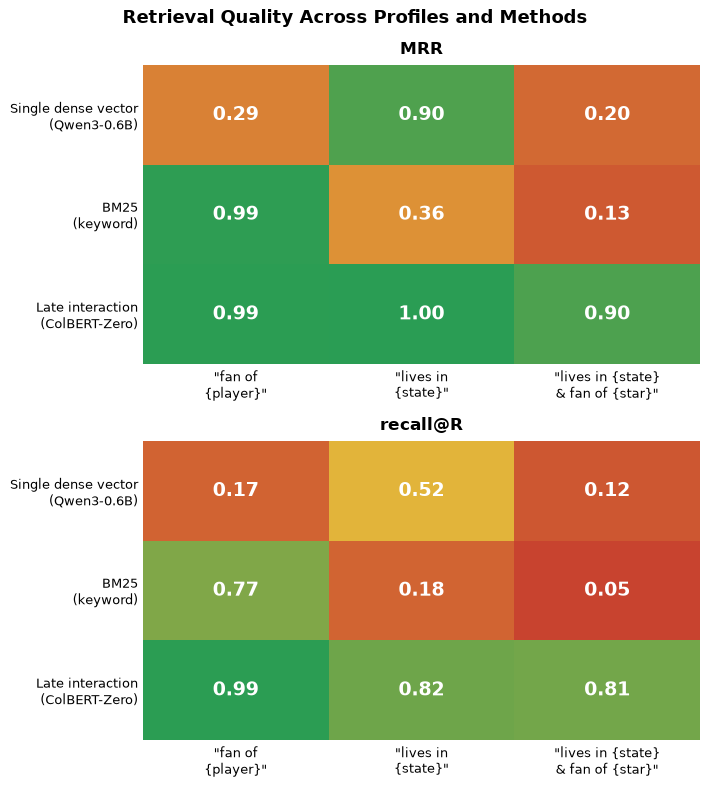

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

col_labels = ['"fan of\n{player}"', '"lives in\n{state}"', '"lives in {state}\n& fan of {star}"']
row_labels = ["Single dense vector\n(Qwen3-0.6B)", "BM25\n(keyword)", "Late interaction\n(ColBERT-Zero)"]
profiles = list(scores)
cmap = LinearSegmentedColormap.from_list("rg", ["#c5392f", "#e8b53a", "#2a9d54"])

fig, axes = plt.subplots(2, 1, figsize=(7.2, 8.0))
for ax, metric in zip(axes, ("MRR", "recall@R")):
    M = np.array([[scores[p][b][metric] for p in profiles] for b in bases])
    ax.imshow(M, cmap=cmap, vmin=0, vmax=1, aspect="auto")
    for i in range(len(bases)):
        for j in range(len(profiles)):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", color="white", fontsize=14, fontweight="bold")
    ax.set_xticks(range(len(profiles)), col_labels, fontsize=9)
    ax.set_yticks(range(len(bases)), row_labels, fontsize=9)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(metric, fontsize=12, fontweight="bold", pad=8)
fig.suptitle("Retrieval Quality Across Profiles and Methods", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 4 · The money shot
*"lives in California, fan of Shai Gilgeous-Alexander"* needs a **semantic** hop
(California → Lakers/Clippers/Warriors/Kings) **and** a **conjunction** (those teams hosting
SGA's Thunder). Watch the top-3.

In [8]:
def nick(tid):  # short team name, e.g. "Lakers"
    return teams[tid].split()[-1]

q = "lives in California, fan of Shai Gilgeous-Alexander"
rel = star_against_state(team_of["Shai Gilgeous-Alexander"], "California")
for base in bases:
    print(f"\n{base}:")
    for g in rank(q, base)[:3]:
        away, home = games[g]
        print(f"   {'✓' if g in rel else ' '} {nick(away)} @ {nick(home)}")
print("\nrelevant =", len(rel), "California-vs-Thunder games")


dense:
     Mavericks @ Lakers
     Mavericks @ Lakers
     Mavericks @ Kings

bm25:
     Thunder @ Mavericks
     Jazz @ Nuggets
     Celtics @ Jazz

late:
   ✓ Thunder @ Lakers
   ✓ Thunder @ Lakers
   ✓ Lakers @ Thunder

relevant = 14 California-vs-Thunder games


## Takeaways
- A single dense vector pools ~30 roster names into one point and loses most of them; a buried
  player's games are hard to surface, and it can't represent a compound profile.
- BM25 is exact-token-only — blind to "California," and easily thrown by repeated names.
- Late interaction keeps a vector per token, so each constraint finds its own evidence. The model is a 150M ColBERT-style encoder.
- Not about basketball: any catalog whose items pack many things into text and whose users ask
  for "A and B that feels like C" has the same shape — jobs, travel, streaming, products.